# Credit Card Fraud Detection - Neural Network Model
This notebook contains the implementation and evaluation of a Multilayer Perceptron (MLP) neural network. It explores algorithmic-level imbalance handling using custom Focal Loss, as well as a data-level comparison using SMOTE.

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid")

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using compute device: {device}")

Using compute device: mps


In [55]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)

    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [56]:
df = pd.read_csv('creditcard.csv')

scaler = StandardScaler()
df['Scaled_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Scaled_Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

df.drop(['Time', 'Amount'], axis=1, inplace=True)
scaled_amount = df.pop('Scaled_Amount')
scaled_time = df.pop('Scaled_Time')
df.insert(0, 'Scaled_Time', scaled_time)
df.insert(1, 'Scaled_Amount', scaled_amount)

X = df.drop('Class', axis=1).values
y = df['Class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1).to(device)

batch_size = 2048
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training tensors created. Shape: {X_train_tensor.shape}")
print(f"Test tensors created. Shape: {X_test_tensor.shape}")
print(f"Batches per epoch: {len(train_loader)}")

Training tensors created. Shape: torch.Size([227845, 30])
Test tensors created. Shape: torch.Size([56962, 30])
Batches per epoch: 112


In [57]:
class FraudMLP(nn.Module):
    def __init__(self, input_size):
        super(FraudMLP, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [58]:
print("Training Standard Neural Network on raw imbalanced data (Standard BCE Loss)...")

set_seed(42)

# Define standard Binary Cross Entropy Loss
criterion_bce = nn.BCEWithLogitsLoss()

# Initialize the model using your exact class name
input_dim = X_train_tensor.shape[1]
base_nn_model = FraudMLP(input_size=input_dim).to(device)
optimizer_base = optim.Adam(base_nn_model.parameters(), lr=0.001)

# Training Loop for Base Model
epochs = 20
base_nn_model.train()
for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer_base.zero_grad()
        outputs = base_nn_model(batch_X)
        loss = criterion_bce(outputs, batch_y)
        loss.backward()
        optimizer_base.step()

# Evaluation for Base Model
base_nn_model.eval()
with torch.no_grad():
    base_nn_logits = base_nn_model(X_test_tensor.to(device))
    base_nn_probs = torch.sigmoid(base_nn_logits).cpu().numpy().squeeze()

# Calculate PR-AUC
from sklearn.metrics import precision_recall_curve, auc
base_nn_precision, base_nn_recall, _ = precision_recall_curve(y_test_numpy, base_nn_probs)
base_nn_pr_auc = auc(base_nn_recall, base_nn_precision)

print(f"Base Neural Network (Standard BCE) PR-AUC: {base_nn_pr_auc:.4f}")

Training Standard Neural Network on raw imbalanced data (Standard BCE Loss)...
Base Neural Network (Standard BCE) PR-AUC: 0.7958


In [59]:
print("Training custom Focal Loss Neural Network...")

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce_with_logits = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce_with_logits(inputs, targets)
        
        pt = torch.exp(-bce_loss) 
        focal_weight = self.alpha * (1 - pt)**self.gamma
        
        focal_loss = focal_weight * bce_loss
        return focal_loss.mean()

Training custom Focal Loss Neural Network...


In [60]:
input_dim = X_train_tensor.shape[1]

set_seed(42)

mlp_model = FraudMLP(input_size=input_dim).to(device)

criterion = FocalLoss(alpha=0.75, gamma=2.0)

learning_rate = 0.001
optimizer = optim.Adam(mlp_model.parameters(), lr=learning_rate)

print(mlp_model)
print(f"Model sent to: {device}")

FraudMLP(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Model sent to: mps


In [61]:
epochs = 20

print("Starting training...")
for epoch in range(epochs):
    mlp_model.train()
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = mlp_model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Average Focal Loss: {avg_loss:.4f}")

print("Training complete!")

Starting training...
Epoch [1/20] - Average Focal Loss: 0.0161
Epoch [5/20] - Average Focal Loss: 0.0009
Epoch [10/20] - Average Focal Loss: 0.0006
Epoch [15/20] - Average Focal Loss: 0.0006
Epoch [20/20] - Average Focal Loss: 0.0005
Training complete!


Neural Network PR-AUC: 0.8518
Default 0.5 Threshold F1-Score: 0.8241
Optimal Threshold: 0.4842 (Yields F1-Score: 0.8300)


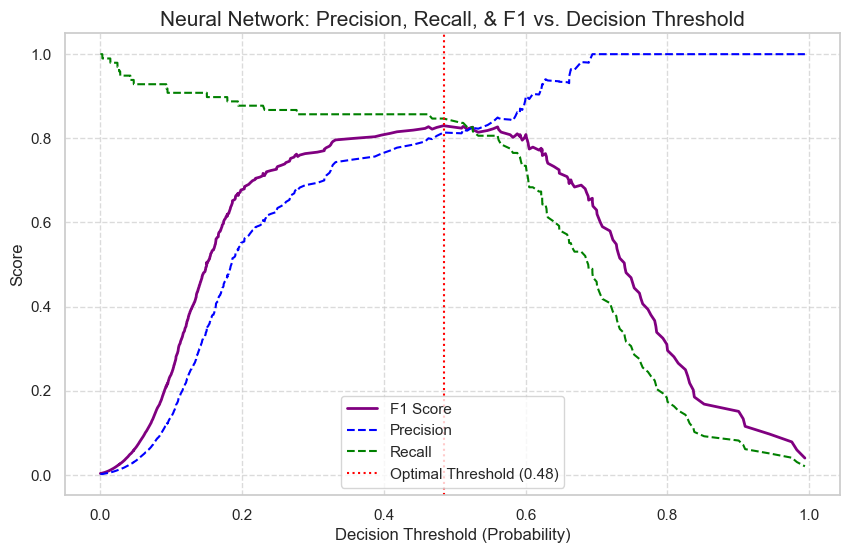

In [62]:
mlp_model.eval()

with torch.no_grad():
    test_logits = mlp_model(X_test_tensor)
    
    nn_probs = torch.sigmoid(test_logits).cpu().numpy().flatten()
    y_test_numpy = y_test_tensor.cpu().numpy().flatten()

nn_precision, nn_recall, nn_thresholds = precision_recall_curve(y_test_numpy, nn_probs)
nn_pr_auc = auc(nn_recall, nn_precision)
print(f"Neural Network PR-AUC: {nn_pr_auc:.4f}")

nn_f1_scores = 2 * (nn_precision[:-1] * nn_recall[:-1]) / (nn_precision[:-1] + nn_recall[:-1] + 1e-8)

nn_optimal_idx = np.argmax(nn_f1_scores)
nn_optimal_threshold = nn_thresholds[nn_optimal_idx]
nn_best_f1 = nn_f1_scores[nn_optimal_idx]

nn_default_idx = np.searchsorted(nn_thresholds, 0.5)
nn_default_f1 = 2 * (nn_precision[nn_default_idx] * nn_recall[nn_default_idx]) / (nn_precision[nn_default_idx] + nn_recall[nn_default_idx] + 1e-8)

print(f"Default 0.5 Threshold F1-Score: {nn_default_f1:.4f}")
print(f"Optimal Threshold: {nn_optimal_threshold:.4f} (Yields F1-Score: {nn_best_f1:.4f})")

plt.figure(figsize=(10, 6))
plt.plot(nn_thresholds, nn_f1_scores, label='F1 Score', color='purple', lw=2)
plt.plot(nn_thresholds, nn_precision[:-1], label='Precision', color='blue', linestyle='--')
plt.plot(nn_thresholds, nn_recall[:-1], label='Recall', color='green', linestyle='--')

plt.axvline(x=nn_optimal_threshold, color='red', linestyle=':', 
            label=f'Optimal Threshold ({nn_optimal_threshold:.2f})')

plt.title('Neural Network: Precision, Recall, & F1 vs. Decision Threshold', fontsize=15)
plt.xlabel('Decision Threshold (Probability)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(loc='lower center')
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig('nn_threshold_tuning.png', dpi=300, bbox_inches='tight')
plt.show()

Focal Loss NN PR-Curve generated and saved successfully!


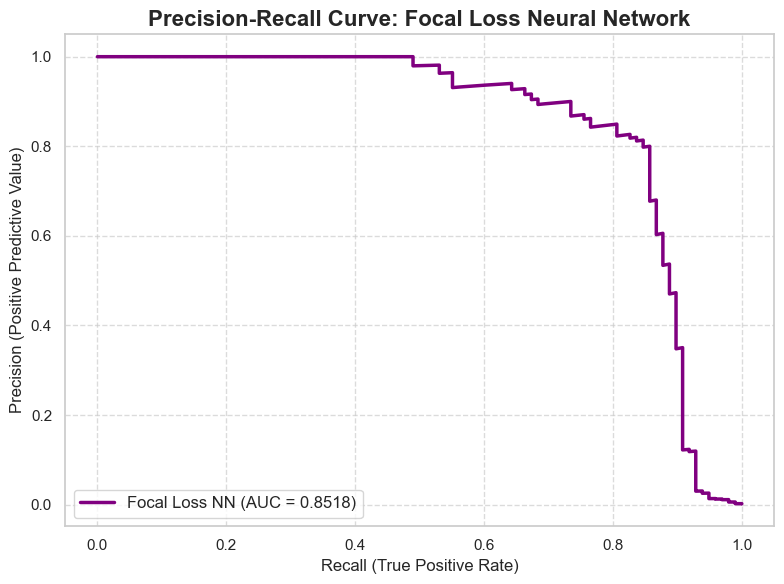

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

precision_nn, recall_nn, _ = precision_recall_curve(y_test_numpy, nn_probs)
pr_auc_nn = auc(recall_nn, precision_nn)

plt.figure(figsize=(8, 6))
plt.plot(recall_nn, precision_nn, color='purple', lw=2.5, label=f'Focal Loss NN (AUC = {pr_auc_nn:.4f})')

plt.title('Precision-Recall Curve: Focal Loss Neural Network', fontsize=16, fontweight='bold')
plt.xlabel('Recall (True Positive Rate)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.legend(loc='lower left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('nn_focal_loss_pr_curve.png', dpi=300, bbox_inches='tight')
print("Focal Loss NN PR-Curve generated and saved successfully!")
plt.show()

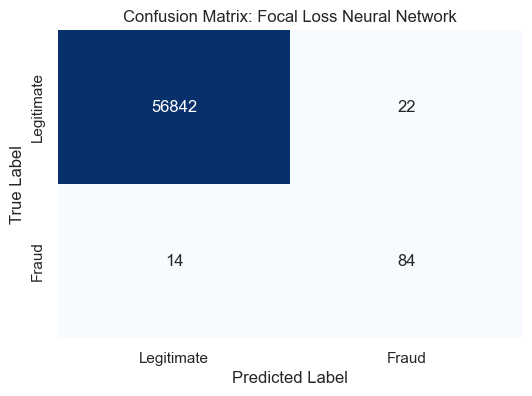

In [64]:
optimal_threshold_fl = 0.4553
nn_predictions = (nn_probs >= optimal_threshold_fl).astype(int)

cm_nn = confusion_matrix(y_test_numpy, nn_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix: Focal Loss Neural Network')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('nn_focal_loss_cm.png', dpi=300, bbox_inches='tight')
plt.show()

In [65]:
from imblearn.over_sampling import SMOTE
import torch.nn as nn
import torch.optim as optim

print("Generating SMOTE data for Neural Network...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

X_train_smote_tensor = torch.FloatTensor(X_train_smote).to(device)
y_train_smote_tensor = torch.FloatTensor(y_train_smote).view(-1, 1).to(device)

smote_train_dataset = TensorDataset(X_train_smote_tensor, y_train_smote_tensor)
smote_train_loader = DataLoader(smote_train_dataset, batch_size=batch_size, shuffle=True)

set_seed(42)

smote_mlp_model = FraudMLP(input_size=input_dim).to(device)
smote_criterion = nn.BCEWithLogitsLoss()
smote_optimizer = optim.Adam(smote_mlp_model.parameters(), lr=0.001)

epochs = 20
print("Starting SMOTE NN training...")
for epoch in range(epochs):
    smote_mlp_model.train()
    total_loss = 0
    
    for batch_X, batch_y in smote_train_loader:
        smote_optimizer.zero_grad()
        predictions = smote_mlp_model(batch_X)
        loss = smote_criterion(predictions, batch_y)
        loss.backward()
        smote_optimizer.step()
        total_loss += loss.item()
        
    avg_loss = total_loss / len(smote_train_loader)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Average BCE Loss: {avg_loss:.4f}")

print("SMOTE NN Training complete!")

Generating SMOTE data for Neural Network...
Starting SMOTE NN training...
Epoch [1/20] - Average BCE Loss: 0.1650
Epoch [5/20] - Average BCE Loss: 0.0139
Epoch [10/20] - Average BCE Loss: 0.0059
Epoch [15/20] - Average BCE Loss: 0.0037
Epoch [20/20] - Average BCE Loss: 0.0024
SMOTE NN Training complete!


In [66]:
smote_mlp_model.eval()

with torch.no_grad():
    smote_test_logits = smote_mlp_model(X_test_tensor)
    smote_nn_probs = torch.sigmoid(smote_test_logits).cpu().numpy().flatten()

smote_nn_precision, smote_nn_recall, smote_nn_thresholds = precision_recall_curve(y_test_numpy, smote_nn_probs)
smote_nn_pr_auc = auc(smote_nn_recall, smote_nn_precision)
print(f"SMOTE Neural Network PR-AUC: {smote_nn_pr_auc:.4f}")

smote_nn_f1_scores = 2 * (smote_nn_precision[:-1] * smote_nn_recall[:-1]) / (smote_nn_precision[:-1] + smote_nn_recall[:-1] + 1e-8)

smote_nn_optimal_idx = np.argmax(smote_nn_f1_scores)
smote_nn_optimal_threshold = smote_nn_thresholds[smote_nn_optimal_idx]
smote_nn_best_f1 = smote_nn_f1_scores[smote_nn_optimal_idx]

smote_nn_default_idx = np.searchsorted(smote_nn_thresholds, 0.5)
smote_nn_default_f1 = 2 * (smote_nn_precision[smote_nn_default_idx] * smote_nn_recall[smote_nn_default_idx]) / (smote_nn_precision[smote_nn_default_idx] + smote_nn_recall[smote_nn_default_idx] + 1e-8)

print(f"Default 0.5 Threshold F1-Score: {smote_nn_default_f1:.4f}")
print(f"Optimal Threshold: {smote_nn_optimal_threshold:.4f} (Yields F1-Score: {smote_nn_best_f1:.4f})")

SMOTE Neural Network PR-AUC: 0.8194
Default 0.5 Threshold F1-Score: 0.7273
Optimal Threshold: 0.9959 (Yields F1-Score: 0.8197)


Updated Ultimate Master PR-Curve generated and saved successfully!


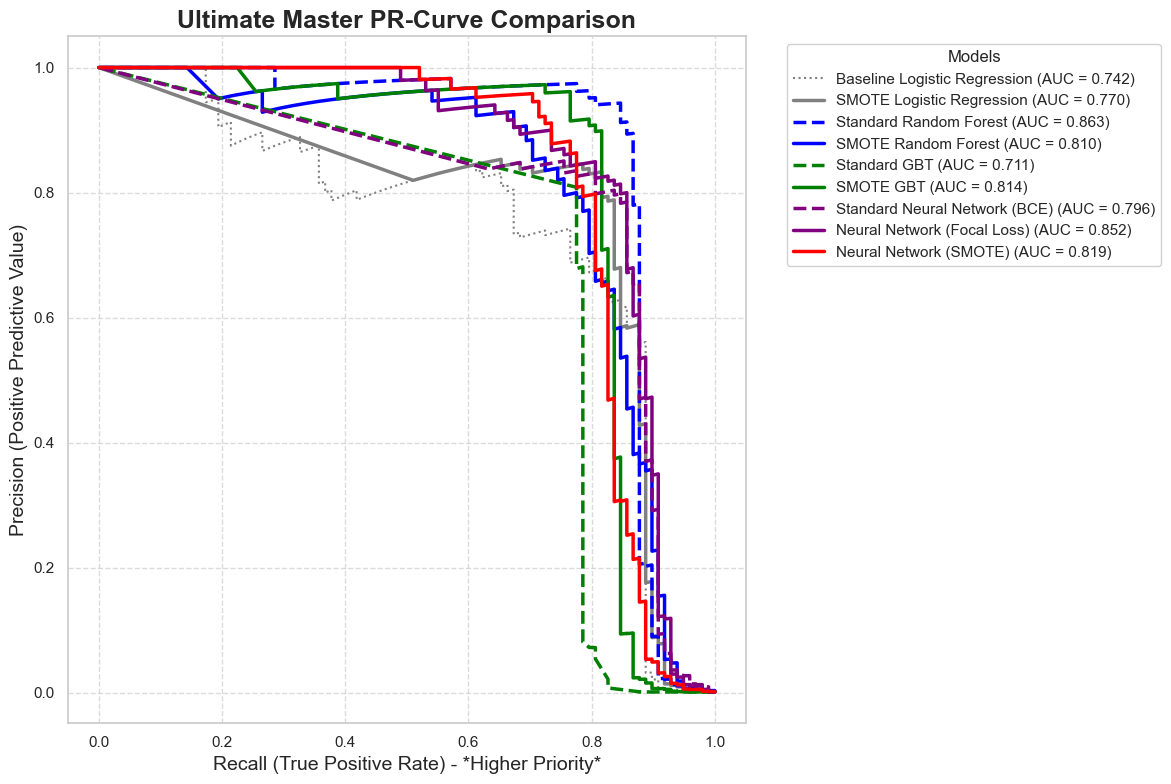

In [67]:
# Cell: ULTIMATE Master PR-Curve (All Models + All Baselines)
# Load baseline predictions from previous notebooks
import numpy as np
baseline_data = np.load('baseline_predictions.npz')
tree_data = np.load('tree_predictions.npz')

baseline_lr_probs = baseline_data['baseline_lr']
smote_lr_probs = tree_data['smote_lr']
rf_base_probs = tree_data['rf_base']
gbt_base_probs = tree_data['gbt_base']
rf_smote_probs = tree_data['rf']
gbt_smote_probs = tree_data['gbt']

# Dictionary of all models
models = {
    'Baseline Logistic Regression': baseline_lr_probs,
    'SMOTE Logistic Regression': smote_lr_probs,
    'Standard Random Forest': rf_base_probs,
    'SMOTE Random Forest': rf_smote_probs,
    'Standard GBT': gbt_base_probs,
    'SMOTE GBT': gbt_smote_probs,
    'Standard Neural Network (BCE)': base_nn_probs,
    'Neural Network (Focal Loss)': nn_probs,
    'Neural Network (SMOTE)': smote_nn_probs
}

plt.figure(figsize=(12, 8))

# Define colors and linestyles (Dashed for base/standard, Solid for imbalance-handled)
colors = ['gray', 'gray', 'blue', 'blue', 'green', 'green', 'purple', 'purple', 'red']
linestyles = [':', '-', '--', '-', '--', '-', '--', '-', '-']

for (name, probs), color, ls in zip(models.items(), colors, linestyles):
    precision, recall, _ = precision_recall_curve(y_test_numpy, probs)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (AUC = {pr_auc:.3f})', color=color, linestyle=ls, lw=2.5 if '-' in ls else 1.5)

plt.title('Ultimate Master PR-Curve Comparison', fontsize=18, fontweight='bold')
plt.xlabel('Recall (True Positive Rate) - *Higher Priority*', fontsize=14)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=14)
# Move legend outside to prevent covering data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, framealpha=0.9, title="Models")
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('ultimate_master_pr_curve_updated.png', dpi=300, bbox_inches='tight')
print("Updated Ultimate Master PR-Curve generated and saved successfully!")
plt.show()

In [68]:
from sklearn.metrics import precision_score, recall_score, f1_score

default_threshold = 0.50

nn_preds_default = (nn_probs >= default_threshold).astype(int)
prec_fl_def = precision_score(y_test_numpy, nn_preds_default)
rec_fl_def = recall_score(y_test_numpy, nn_preds_default)
f1_fl_def = f1_score(y_test_numpy, nn_preds_default)

print("--- PRE-OPTIMIZED NEURAL NETWORK (FOCAL LOSS) ---")
print(f"Default Threshold:   {default_threshold:.2f}")
print(f"Default Precision:   {prec_fl_def:.4f}")
print(f"Default Recall:      {rec_fl_def:.4f}")
print(f"Default F1-Score:    {f1_fl_def:.4f}\n")

smote_nn_preds_default = (smote_nn_probs >= default_threshold).astype(int)
prec_sm_def = precision_score(y_test_numpy, smote_nn_preds_default)
rec_sm_def = recall_score(y_test_numpy, smote_nn_preds_default)
f1_sm_def = f1_score(y_test_numpy, smote_nn_preds_default)

print("--- PRE-OPTIMIZED NEURAL NETWORK (SMOTE) ---")
print(f"Default Threshold:   {default_threshold:.2f}")
print(f"Default Precision:   {prec_sm_def:.4f}")
print(f"Default Recall:      {rec_sm_def:.4f}")
print(f"Default F1-Score:    {f1_sm_def:.4f}")

--- PRE-OPTIMIZED NEURAL NETWORK (FOCAL LOSS) ---
Default Threshold:   0.50
Default Precision:   0.8119
Default Recall:      0.8367
Default F1-Score:    0.8241

--- PRE-OPTIMIZED NEURAL NETWORK (SMOTE) ---
Default Threshold:   0.50
Default Precision:   0.6557
Default Recall:      0.8163
Default F1-Score:    0.7273


In [69]:
from sklearn.metrics import precision_recall_curve
import numpy as np

prec_fl, rec_fl, thresh_fl = precision_recall_curve(y_test_numpy, nn_probs)
f1_fl = 2 * (prec_fl[:-1] * rec_fl[:-1]) / (prec_fl[:-1] + rec_fl[:-1] + 1e-8)
opt_idx_fl = np.argmax(f1_fl)

print("--- NEURAL NETWORK (FOCAL LOSS) ---")
print(f"Optimal Threshold:   {thresh_fl[opt_idx_fl]:.4f}")
print(f"Optimized Precision: {prec_fl[opt_idx_fl]:.4f}")
print(f"Optimized Recall:    {rec_fl[opt_idx_fl]:.4f}")
print(f"Peak F1-Score:       {f1_fl[opt_idx_fl]:.4f}\n")

prec_sm, rec_sm, thresh_sm = precision_recall_curve(y_test_numpy, smote_nn_probs)
f1_sm = 2 * (prec_sm[:-1] * rec_sm[:-1]) / (prec_sm[:-1] + rec_sm[:-1] + 1e-8)
opt_idx_sm = np.argmax(f1_sm)

print("--- NEURAL NETWORK (SMOTE) ---")
print(f"Optimal Threshold:   {thresh_sm[opt_idx_sm]:.4f}")
print(f"Optimized Precision: {prec_sm[opt_idx_sm]:.4f}")
print(f"Optimized Recall:    {rec_sm[opt_idx_sm]:.4f}")
print(f"Peak F1-Score:       {f1_sm[opt_idx_sm]:.4f}")

--- NEURAL NETWORK (FOCAL LOSS) ---
Optimal Threshold:   0.4842
Optimized Precision: 0.8137
Optimized Recall:    0.8469
Peak F1-Score:       0.8300

--- NEURAL NETWORK (SMOTE) ---
Optimal Threshold:   0.9959
Optimized Precision: 0.8824
Optimized Recall:    0.7653
Peak F1-Score:       0.8197
